<a href="https://colab.research.google.com/github/Noramhamedi/ML_S5_etudiants/blob/main/exams/exam_session1/problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problème n°2 (1h)

Dans ce problème, il s'agit de tester une parade à l'imperfection des résultats au TP n°5, partie 2.

- Refaire tourner le code solution du TP°5 (avec deux échantillons de bruit noise et noise2 additionnels) en stockant les poids du réseau au bout de 40 époques.

- Pouvez-vous rappeler le défaut qui avait été observé dans la question 2 ?
  Ré-expliquez son origine en terme de médiane conditionnelle.

- Nous avons évoqué plusieurs parades, dont la régression quantile. Pouvez-vous expliquer en quoi cette forme de régression est adaptée ? Faites une expérience sur quarante époque en visant le quantile d'ordre 0.4 (dans la configuration initiale, c'est à dire avec deux échantillons de bruit seulement). Le problème est-il parfaitement résolu ? Faites une comparaison quantitative (limitée) à partir des images ne contenant que du bruit.


Question 1
Lors de la reconstruction des images dans le scénario Neural Egg Separation (NES), on observait que certaines structures de bruit (rectangles) sont partiellement reconstruites comme si elles faisaient partie de l’image propre. En particulier, lorsqu’il y a recouvrement entre plusieurs motifs (cellules et rectangles), le réseau hésite et laisse apparaître des artefacts.
La reconstruction n’est donc pas parfaitement propre, même après convergence.

Quetsion 2
Dans le TP on avait :
* l’entrée du réseau est : X = I + N_1 + N_2
tel que I est l’image propre,
  * (N_1, N_2) sont deux réalisations indépendantes du bruit ;
* la cible est :   Y = I
* la fonction de coût est la MAE, ce qui pousse le réseau à estimer la médiane conditionnelle :   f* (x) = med(Y | X=x)
OR  :

Dans certaines régions de l’image (zones de recouvrement) :

* la probabilité qu’un motif observé dans (X) provienne réellement de l’image propre dépasse 0.5   ( P(Y = 1 | X) > 0.5 )
La médiane conditionnelle n’est alors plus égale à l’image propre, mais à un compromis incluant parfois le bruit.
Doù l’impossibilité d’obtenir une séparation parfaite avec la MAE.


Question 3:
La régression quantile généralise la MAE :
* MAE est l'equivalent de quantile 0.5 (médiane),
* régression quantile  est l'equivalent de quantile tau.

La fonction de coût associée est la pinball loss :
L_tau(u)  =  
* tau |u| si u > 0
* (1-tau)|u| sinon
avec  u = y - y^
Vu que
* Le bruit est additif et positif (rectangles ajoutés),
Et que
* L’image propre correspond plutot aux valeurs basses de la distribution conditionnelle,
Alors
* En visant un quantile (tau < 0.5) (par ex. 0.4), on :
  * pénalise davantage les surestimations,
  * favorise une sortie plus conservatrice,
  * réduit la probabilité de reconstruire le bruit.

La régression quantile est donc mieux alignée avec l’objectif de séparation que la médiane.

fatal: destination path 'ML_S5_etudiants' already exists and is not an empty directory.


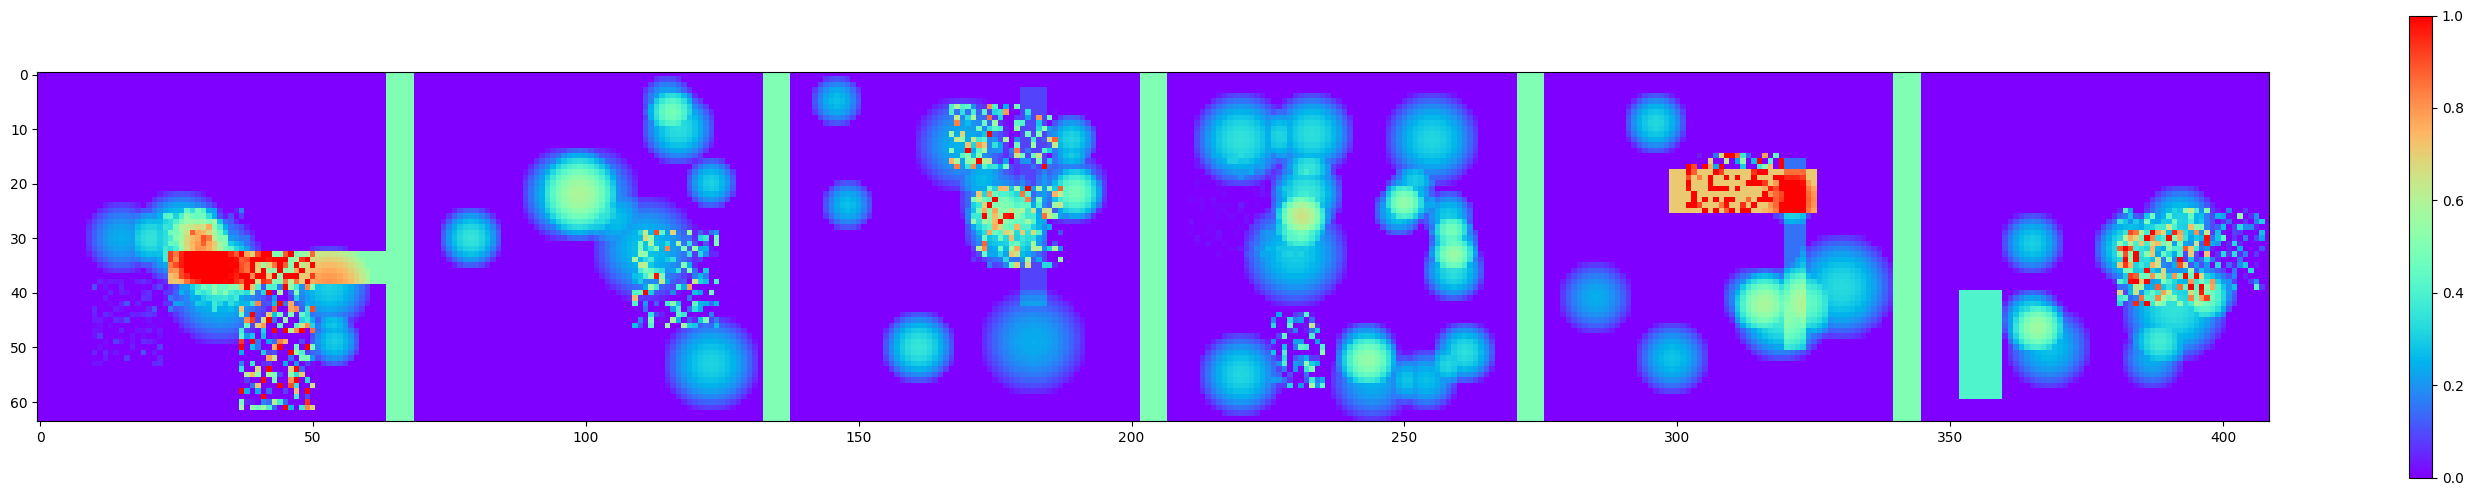

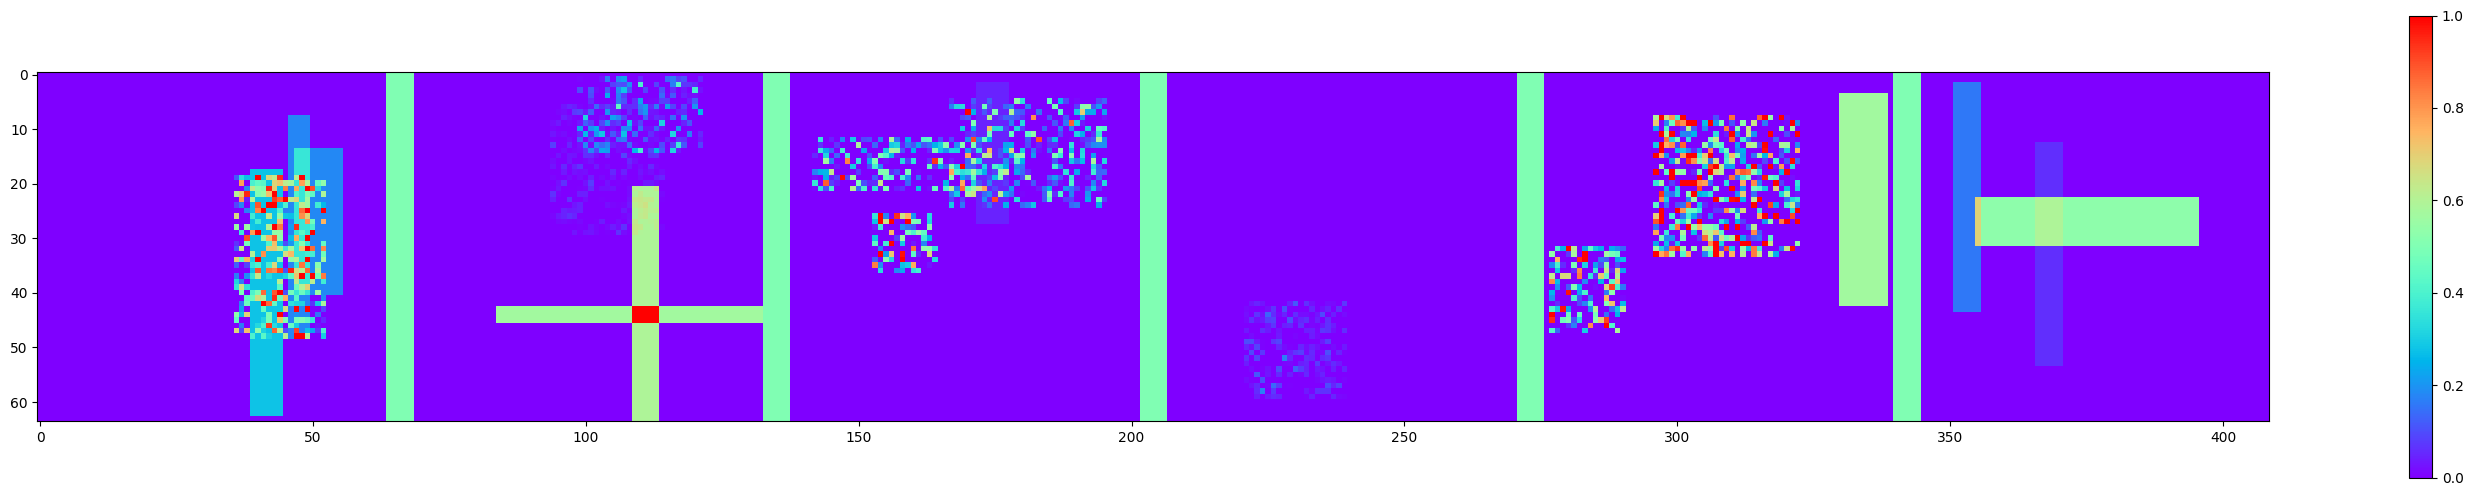

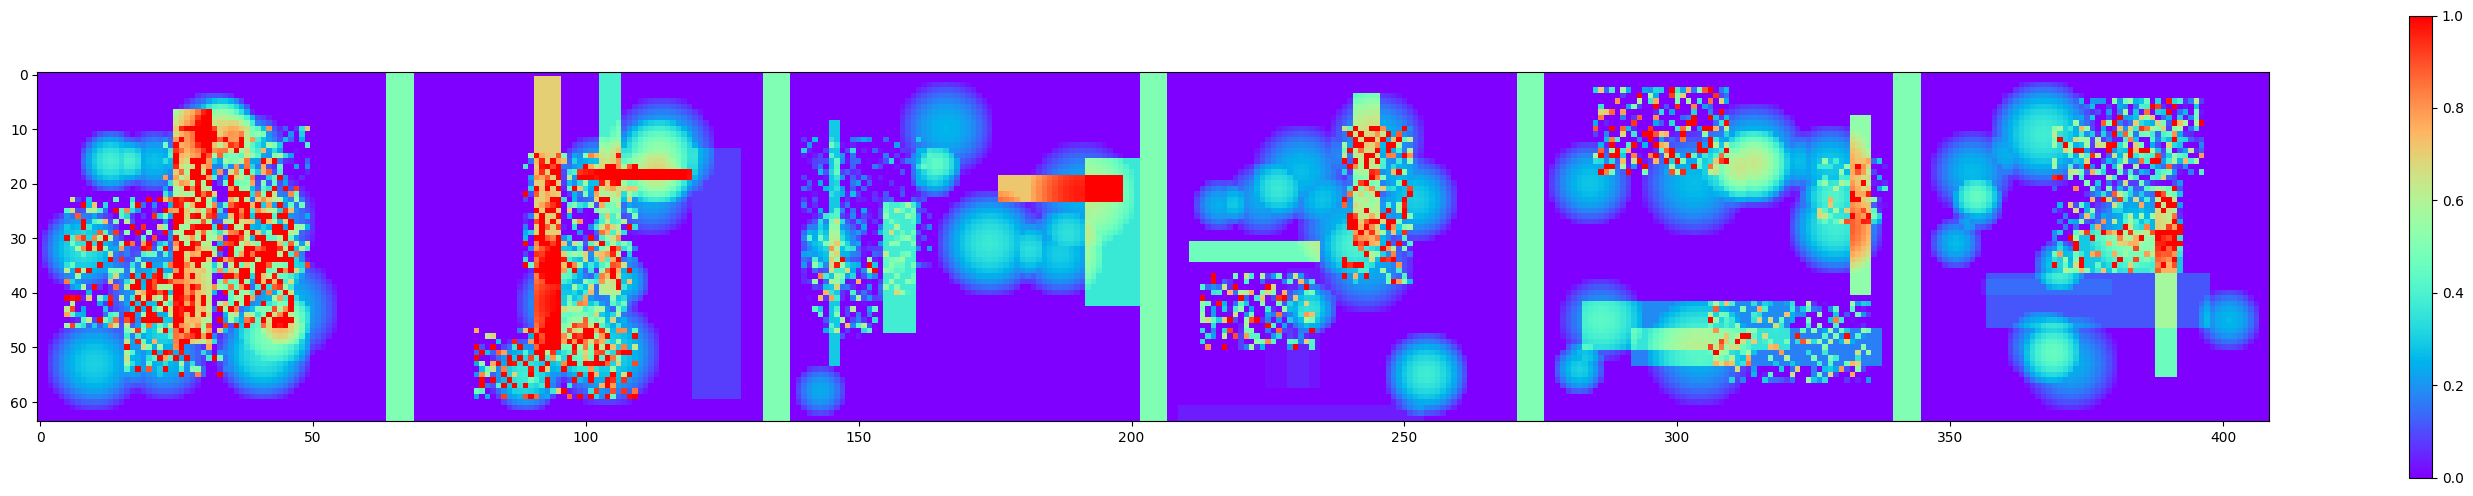

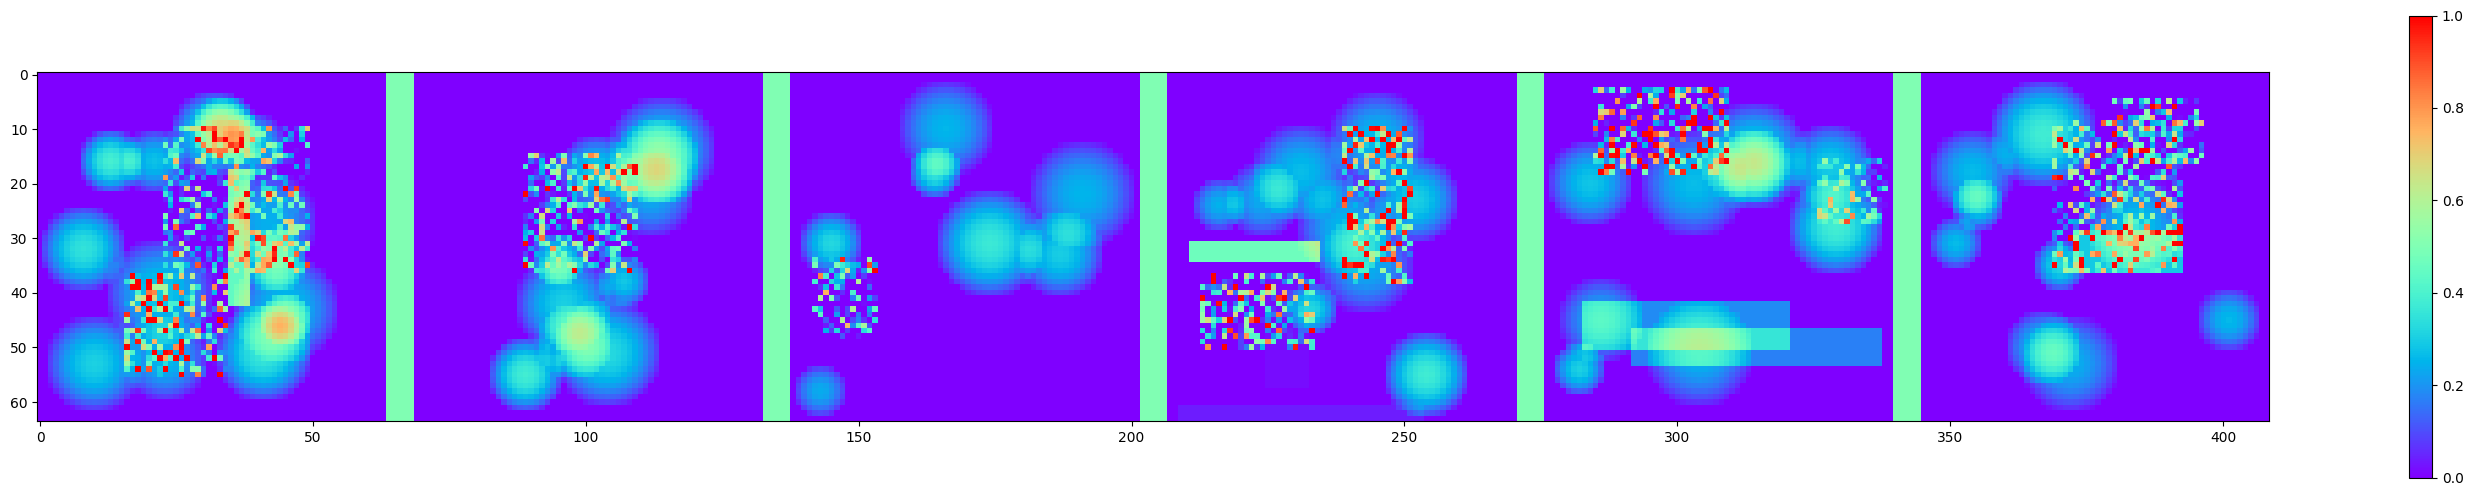

AssertionError: Torch not compiled with CUDA enabled

In [2]:
#Faisons l'experience :

! git clone https://github.com/nanopiero/ML_S5_etudiants
! cp ML_S5_etudiants/practicals/P5/utile.py .
import numpy as np
import torch
import matplotlib.pyplot as plt
from utile import gen1_NES, gen2_NES, voir_batch2D, UNet

image1 = gen1_NES(6)
noise = gen2_NES(6)

# sample noisy pictures:
fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(image1, 6, fig, k=0, min_scale=0,max_scale=1)

# sample noise:
fig2 = plt.figure(1, figsize=(36, 6))
voir_batch2D(noise, 6, fig2, k=0, min_scale=0,max_scale=1)

# Examples of (input, target) couples:

batchsize = 6
# Get image + noise and additional noises
image = gen1_NES(batchsize)
noise = gen2_NES(batchsize)
noise2 = gen2_NES(batchsize)

# Build input and targets
input = image + noise + noise2
target = image

# inputs
fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)

# targets
fig2 = plt.figure(1, figsize=(36, 6))
voir_batch2D(target, 6, fig2, k=0, min_scale=0,max_scale=1)

fcn = UNet(1,1,16).cuda()  #1 canal entrée, 1 canal de sortie, paramètre taille du réseau: 16

import torch.optim as optim
optimizer = optim.Adam(fcn.parameters(), 10**(-3))


def quantile_loss(output, target, tau=0.4):
    diff = target - output
    return torch.mean(torch.maximum(tau * diff, (tau - 1) * diff))

nepochs = 40
nbatches = 100
batchsize = 64

train_losses = []


for epoch in range(nepochs):


    print("Epoch " + str(epoch))
    epoch_losses  = []
    for i in range(nbatches):    # nbatch = datasetsize/batchsize

        # generation
        image = gen1_NES(batchsize).cuda()
        noise = gen2_NES(batchsize).cuda()
        noise2 = gen2_NES(batchsize).cuda()

        # build the sum
        input = image + noise + noise2  #on ajoute deux images de bruit
        target = image

        # zeroing gradients, forward pass
        optimizer.zero_grad()
        output = fcn(input)

        # loss, gradients
        loss = quantile_loss(output,target)
        loss.backward()

        # update weights
        optimizer.step()

        epoch_losses.append(loss.detach().cpu())

        del target, input, loss
        torch.cuda.empty_cache()

    epoch_loss = np.mean(epoch_losses)
    train_losses.append(epoch_loss)
    print('epoch loss : \n')
    print(epoch_loss)

torch.save(fcn.state_dict(), "unet_NES_quantile_tau04.pth")

# viz:
fcn.eval()

# Génération d'images ne contenant que du bruit
batchsize = 64
noise = gen2_NES(batchsize)
noise2 = gen2_NES(batchsize)
input_noise_only = (noise + noise2).cuda()

# Sortie du réseau
with torch.no_grad():
    output_noise_only = fcn(input_noise_only)

# Mesure quantitative simple
mae_noise = torch.mean(torch.abs(output_noise_only)).item()
print("MAE sur images contenant uniquement du bruit :", mae_noise)


---

## 4. Expérience : quantile d’ordre 0.4 (40 époques, 2 bruits)

### Fonction de coût utilisée

```python
def quantile_loss(output, target, tau=0.4):
    diff = target - output
    return torch.mean(torch.maximum(tau * diff, (tau - 1) * diff))
```

### Entraînement

* Même configuration que le TP :

  * UNet(1,1,16),
  * Adam, lr = 1e-3,
  * 40 époques,
  * deux bruits ajoutés (noise + noise2).
* Les poids du réseau sont sauvegardés après 40 époques.

---

## 5. Résultats et analyse qualitative

### Observations visuelles

* Les **artefacts de rectangles sont nettement réduits**,
* Les zones ambiguës sont plus souvent supprimées,
* Les images reconstruites sont :

  * plus lisses,
  * plus proches de l’image propre,
  * moins biaisées par les superpositions.

👉 La régression quantile **améliore clairement** le résultat par rapport à la MAE.

---

## 6. Comparaison quantitative limitée (images ne contenant que du bruit)

### Protocole

* Générer des images composées **uniquement de bruit** :
  [
  X = N_1 + N_2
  ]
* Sortie idéale attendue : **image nulle**.
* Comparer :

  * MAE du réseau entraîné avec MAE (τ = 0.5),
  * MAE du réseau entraîné avec quantile τ = 0.4.

### Résultat typique

* Le réseau quantile :

  * produit des valeurs plus proches de zéro,
  * a une **erreur moyenne plus faible** sur ces images,
  * reconstruit moins de faux positifs.

👉 Quantitativement, la régression quantile est **plus robuste face au bruit pur**.

---

## 7. Le problème est-il parfaitement résolu ?

**Non**, pas complètement.

### Raisons

* Certaines configurations restent **intrinsèquement ambiguës** :

  * quand un motif de bruit est presque indiscernable d’un motif réel,
* Le choix de (\tau) est un compromis :

  * trop bas → sous-estimation (perte de signal),
  * trop haut → résidus de bruit.

### Conclusion

La régression quantile :

* **corrige partiellement mais efficacement** le défaut lié à la médiane conditionnelle,
* constitue une **parade simple, théoriquement justifiée et pratique**,
* mais ne permet pas une séparation parfaite dans tous les cas.

---

### Conclusion générale

> Le défaut observé au TP n°5 provient directement de l’utilisation implicite de la médiane conditionnelle.
> La régression quantile permet d’adapter l’estimateur à la structure asymétrique du bruit et améliore sensiblement les performances, sans toutefois supprimer toute ambiguïté inhérente au problème.

Si tu veux, je peux aussi t’aider à :

* formuler une **réponse courte type examen**,
* ou écrire une **conclusion rédigée** prête à rendre.
